# Fusion

## Imports et chargements datasets

In [1]:
## Imports et configuration
import pandas as pd
import numpy as np
import sys
from pathlib import Path
import time
import os

# Visuels
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# === CONFIGURATION PROJET ===
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

abs# === SKLEARN - PREPROCESSING ===
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# === SKLEARN - MODÈLES ===
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

# === SKLEARN - MÉTRIQUES ===
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from config.paths import DONNEES_PROCESSED
from config.config import RANDOM_STATE, RAINFALL_TOLERANCE, TEMP_TOLERANCE

In [2]:
df_fao_consolidated = pd.read_csv(DONNEES_PROCESSED / "df_fao_consolidated.csv")
df_historiques = pd.read_csv(DONNEES_PROCESSED / "historical_clean.csv")

In [3]:
df_fao_consolidated.head()

,Area,Item,Year,yield_hg_per_ha,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613.0,1485.0,121.0,16.37
1,Albania,Maize,1991,29068.0,1485.0,121.0,15.36
2,Albania,Maize,1992,24876.0,1485.0,121.0,16.06
3,Albania,Maize,1993,24185.0,1485.0,121.0,16.05
4,Albania,Maize,1994,25848.0,1485.0,201.0,16.96


In [4]:
df_exemple_france = df_fao_consolidated[df_fao_consolidated['Area'] == 'France']

In [5]:
df_exemple_france.head()

,Area,Item,Year,yield_hg_per_ha,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
3977,France,Maize,1990,60186.0,867.0,97701.0,11.96
3978,France,Maize,1991,72866.0,867.0,103434.0,10.60
3979,France,Maize,1992,79812.0,867.0,85249.0,11.15
3980,France,Maize,1993,80479.0,867.0,91953.0,10.70
3981,France,Maize,1994,77983.0,867.0,89515.0,11.96


## Analyse de la Compatibilité FAO vs Simulateur

### Dictionnaire des variables clés

In [6]:
DURATION_MEAN = df_historiques['Days_to_Harvest'].mean()
TEMP_FAO_MEAN = df_fao_consolidated['avg_temp'].mean()
TEMP_HIST_MEAN = df_historiques['Temperature_Celsius'].mean()
OFFSET_TEMP = TEMP_HIST_MEAN - TEMP_FAO_MEAN
print(f"Duréee de récolte moyenne : {round(DURATION_MEAN)} jours")
print(f"Température moyenne FAO : {round(TEMP_FAO_MEAN)} degrés Celsius")
print(f"Température moyenne Historique : {round(TEMP_HIST_MEAN)} degrés Celsius")
print(f"Ecart des moyennes (moy. histo - moy. FAO) : {round(OFFSET_TEMP)} degrés Celsius")

Duréee de récolte moyenne : 104 jours
Température moyenne FAO : 20 degrés Celsius
Température moyenne Historique : 28 degrés Celsius
Ecart des moyennes (moy. histo - moy. FAO) : 8 degrés Celsius


In [7]:
# On crée les nouvelles variables de températures
# Et de pluie remenées à la période de récolte
df_fao_consolidated['Temp_Cycle'] = df_fao_consolidated.avg_temp + OFFSET_TEMP
df_fao_consolidated['Rain_Cycle'] = df_fao_consolidated.average_rain_fall_mm_per_year * (DURATION_MEAN / 365)

### Définition des cultures communes
Peu de colonnes, on va déterminer les communes manuellement

In [8]:
df_historiques['Crop'].unique()

array(['Cotton', 'Rice', 'Barley', 'Soybean', 'Wheat', 'Maize'],
      dtype=object)

In [9]:
df_fao_consolidated['Item'].unique()

array(['Maize', 'Potatoes', 'Rice, paddy', 'Sorghum', 'Soybeans', 'Wheat',
       'Cassava', 'Sweet potatoes', 'Plantains and others', 'Yams'],
      dtype=object)

In [10]:
print("🔍 STANDARDISATION DES CULTURES (FAO -> Simulateur)")

# 1. Dictionnaire de Mapping (La Vérité Terrain)
# Clé = Nom dans la FAO  -->  Valeur = Nom dans le Simulateur
# Ce qui n'est PAS dans ce dictionnaire sera supprimé.
crop_mapping = {
    'Maize': 'Maize',            # Match parfait
    'Wheat': 'Wheat',            # Match parfait
    'Rice, paddy': 'Rice',       # Harmonisation (Virgule supprimée)
    'Soybeans': 'Soybean'        # Harmonisation (Pluriel supprimé)
}

# 2. Filtrage (On ne garde que les clés du dictionnaire)
initial_count = len(df_fao_consolidated)
df_fao_consolidated = df_fao_consolidated[df_fao_consolidated['Item'].isin(crop_mapping.keys())].copy()

# 3. Renommage (On applique la standardisation)
df_fao_consolidated['Item'] = df_fao_consolidated['Item'].map(crop_mapping)

# 4. Rapport
final_count = len(df_fao_consolidated)
dropped_count = initial_count - final_count

print(f"-------------------------------------------------------")
print(f"✅ Cultures retenues et harmonisées : {list(crop_mapping.values())}")
print(f"🗑️ Lignes FAO supprimées (Cultures hors scope ex: Potatoes, Yams...) : {dropped_count}")
print(f"📉 Dataset FAO prêt pour fusion : {final_count} lignes")
print(f"-------------------------------------------------------")

# Vérification ultime
print("Vérification des noms uniques dans FAO après nettoyage :")
print(df_fao_consolidated['Item'].unique())

🔍 STANDARDISATION DES CULTURES (FAO -> Simulateur)
-------------------------------------------------------
✅ Cultures retenues et harmonisées : ['Maize', 'Wheat', 'Rice', 'Soybean']
🗑️ Lignes FAO supprimées (Cultures hors scope ex: Potatoes, Yams...) : 6498
📉 Dataset FAO prêt pour fusion : 6532 lignes
-------------------------------------------------------
Vérification des noms uniques dans FAO après nettoyage :
['Maize' 'Rice' 'Soybean' 'Wheat']


Choix Méthodologique (Périmètre) : On restreint volontairement le modèle à l'intersection stricte des cultures présentes dans les deux datasets. Le simulateur agissant comme notre "Vérité Terrain" (Ground Truth) pour l'apprentissage des courbes de réponse climatique, inclure des cultures non-simulées reviendrait à demander au modèle de prédire des comportements physiques qu'il n'a jamais appris, ce qui compromettrait la fiabilité globale des prédictions.

### Analyse des distributions de températures

#### Visualisation

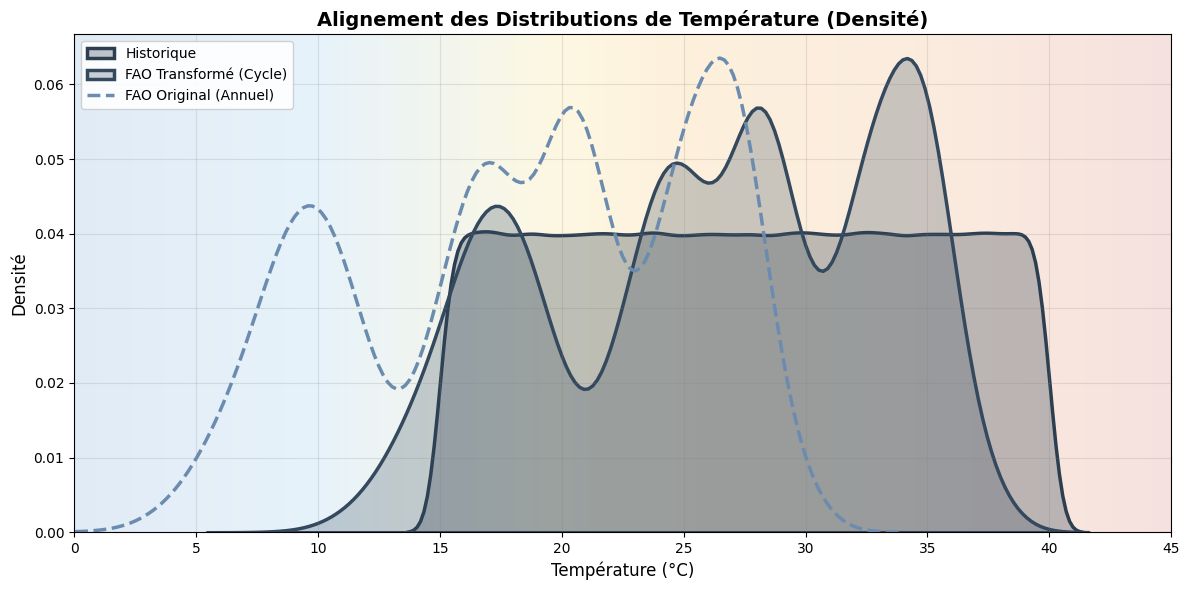

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))

# TRACER LES COURBES ===
sns.kdeplot(df_historiques['Temperature_Celsius'], 
            color='#2C3E50', linewidth=2.5,
            label='Historique', fill=True, alpha=0.3, ax=ax)

sns.kdeplot(df_fao_consolidated['Temp_Cycle'], 
            color='#34495E', linewidth=2.5,
            label='FAO Transformé (Cycle)', fill=True, alpha=0.25, ax=ax)

sns.kdeplot(df_fao_consolidated['avg_temp'], 
            color='#6B8CAE', linewidth=2.5,
            label='FAO Original (Annuel)', linestyle='--', ax=ax)

# === Ajout du fond ===
temp_min, temp_max = 0, 45
ylim_max = ax.get_ylim()[1] 

gradient = np.linspace(0, 1, 256).reshape(1, -1)
gradient = np.vstack((gradient, gradient))

cmap = LinearSegmentedColormap.from_list('thermal', 
    [
        (0.0, '#3A7BC8'),   # 0°C - Bleu froid intense
        (0.22, '#5DADE2'),  # ~10°C - Bleu clair
        (0.44, '#F4D03F'),  # ~20°C - Jaune
        (0.56, '#F39C12'),  # ~25°C - Orange
        (0.78, '#E67E22'),  # ~35°C - Orange intense
        (1.0, '#C0392B')    # 45°C - Rouge très chaud
    ])

ax.imshow(gradient, aspect='auto', cmap=cmap, 
          extent=[temp_min, temp_max, 0, ylim_max], 
          alpha=0.15, zorder=-1)  # zorder=-1 = derrière tout

ax.set_title("Alignement des Distributions de Température (Densité)", 
             fontsize=14, fontweight='bold')
ax.set_xlabel("Température (°C)", fontsize=12)
ax.set_ylabel("Densité", fontsize=12)
ax.legend(loc='upper left', framealpha=0.9)
ax.grid(True, alpha=0.2, color='gray', linewidth=0.8)
plt.tight_layout()
plt.show()

On voit qu'il y a quelques températures basses en dehors de la courbe historique, ce qui veut dire que celles-ci ne pourront être rapprochées pendant la fusion, on va les examiner de plus près

#### Visualisations pour les températures froides

In [12]:
df_temp_basses = df_fao_consolidated[df_fao_consolidated['Temp_Cycle'] < 15].copy()

C:\Users\Fab\AppData\Local\Temp\ipykernel_16612\3187767564.py:12: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  sns.boxplot(data=df_temp_basses, palette=couleurs_cultures_givrees, hue="Item", x='Item', y='yield_hg_per_ha', ax=ax)


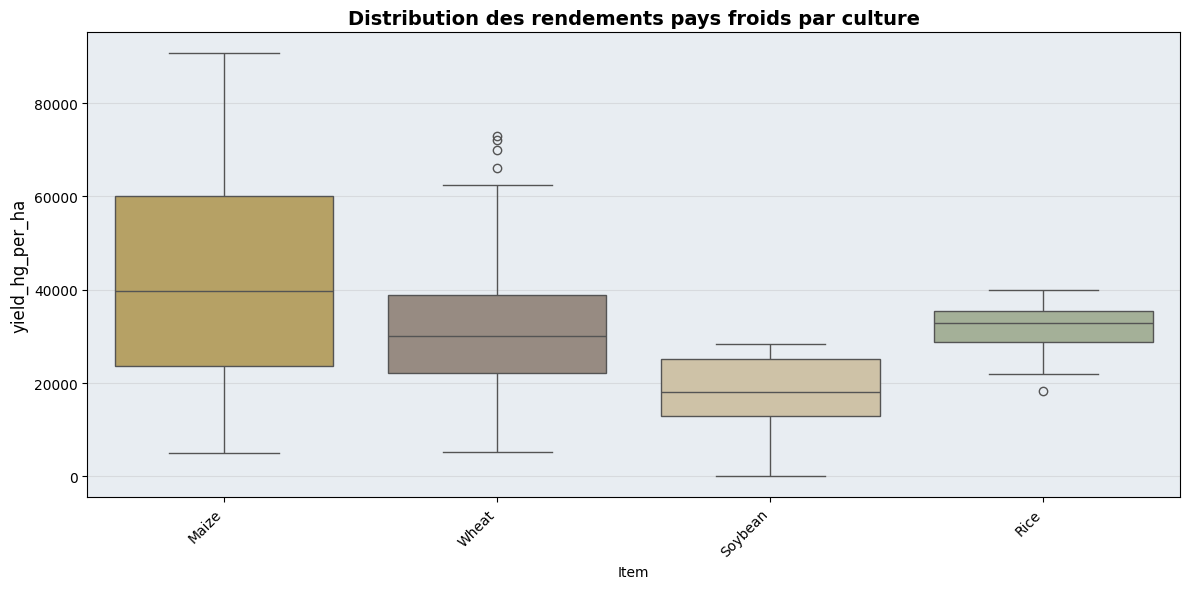

In [13]:
# Boxplot PAR CULTURE (essentiel pour données agricoles)
couleurs_cultures_givrees = [
    '#C4A857',  # Maize - jaune maïs délavé/givré
    '#9B8B7E',  # Potatoes - brun terreux grisé
    '#D4C4A0',  # Wheat - doré pâle hivernal
    '#A4B494',  # Soybeans - vert olive délavé
    '#D9CDB8',  # Rice - beige très pâle (riz cuit refroidi)
    '#B08B7A'   # Sorghum - rouge-brun délavé
]
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_facecolor('#E8EDF2')
sns.boxplot(data=df_temp_basses, palette=couleurs_cultures_givrees, hue="Item", x='Item', y='yield_hg_per_ha', ax=ax)
plt.xticks(rotation=45, ha='right')
plt.ylabel('yield_hg_per_ha', fontsize=12)
plt.title('Distribution des rendements pays froids par culture', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

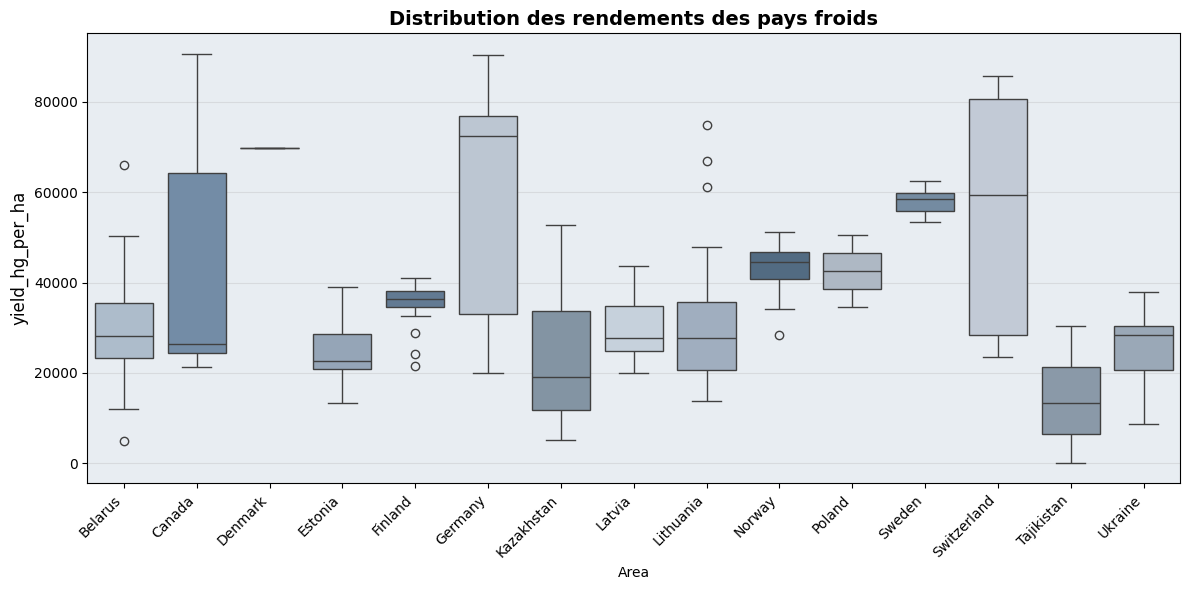

In [14]:
# Boxplot rendements par pays froids
couleurs_pays_nordiques = [
    '#A8BCD0',  # Belarus - bleu glacier pâle
    '#6B8CAE',  # Canada - bleu moyen froid
    '#D0D8E0',  # Denmark - gris-bleu très clair
    '#8FA5BD',  # Estonia - bleu-gris délavé
    '#5A7A9B',  # Finland - bleu profond nordique
    '#B8C5D6',  # Germany - bleu brumeux
    '#7E94A8',  # Kazakhstan - bleu acier
    '#C2D1E0',  # Latvia - bleu glacier très pâle
    '#9BAEC4',  # Lithuania - bleu-gris moyen
    '#4A6B8A',  # Norway - bleu fjord profond
    '#AAB8C8',  # Poland - gris-bleu neutre
    '#6D8BA8',  # Sweden - bleu nordique classique
    '#BFC9D9',  # Switzerland - bleu montagne pâle
    '#8599AD',  # Tajikistan - bleu-gris froid
    '#95A8BC'   # Ukraine - bleu steppe hivernal
]
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_facecolor('#E8EDF2')
sns.boxplot(data=df_temp_basses, palette=couleurs_pays_nordiques, hue='Area', x='Area', y='yield_hg_per_ha', ax=ax)
plt.xticks(rotation=45, ha='right')
plt.ylabel('yield_hg_per_ha', fontsize=12)
plt.title('Distribution des rendements des pays froids', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Conclusion :** L'analyse révèle une incompatibilité structurelle pour les températures < 15°C, zone non couverte par le simulateur historique. Nous exclurons ces données (principalement pays nordiques) pour restreindre le modèle à son domaine de validité strict, garantissant ainsi la fiabilité des prédictions sur les zones tempérées et chaudes.

### Analyse des distributions de pluviométries

#### Visualisation

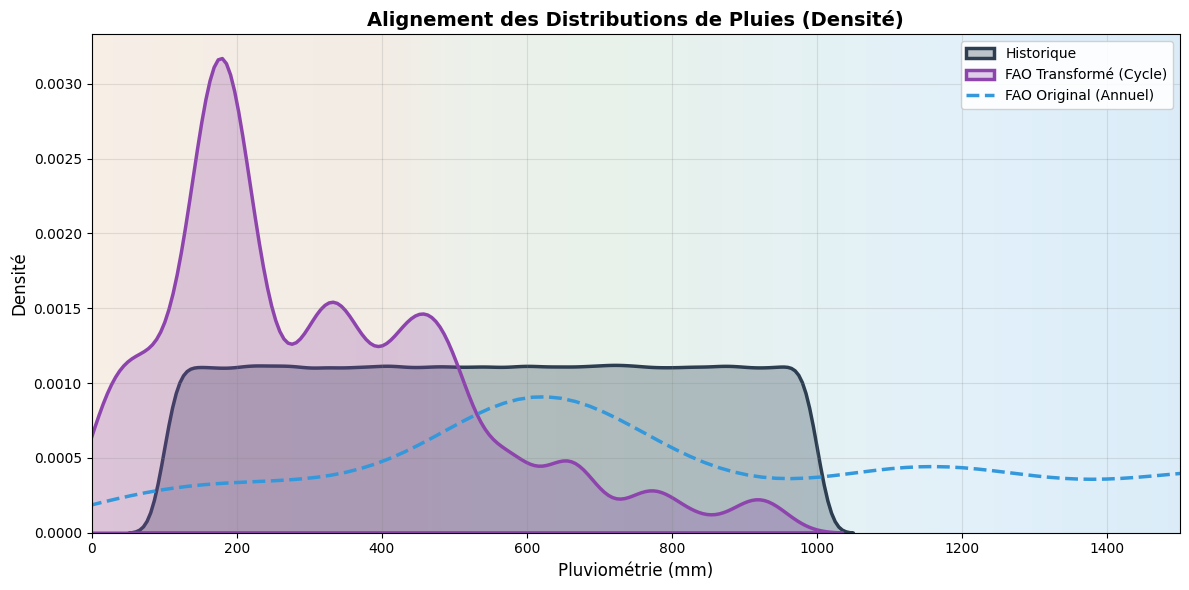

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))

# === ÉTAPE 1 : TRACER LES COURBES D'ABORD ===
sns.kdeplot(df_historiques['Rainfall_mm'], 
            color='#2C3E50', linewidth=2.5,
            label='Historique', fill=True, alpha=0.3, ax=ax)

sns.kdeplot(df_fao_consolidated['Rain_Cycle'], 
            color='#8E44AD', linewidth=2.5,  # VIOLET
            label='FAO Transformé (Cycle)', fill=True, alpha=0.25, ax=ax)

sns.kdeplot(df_fao_consolidated['average_rain_fall_mm_per_year'], 
            color='#3498DB', linewidth=2.5,
            label='FAO Original (Annuel)', linestyle='--', ax=ax)

# === ÉTAPE 2 : AJOUTER LE FOND (adapté à la nouvelle échelle) ===
rain_min, rain_max = 0, 1500  # Coupé à 1500mm
ylim_max = ax.get_ylim()[1]

gradient = np.linspace(0, 1, 256).reshape(1, -1)
gradient = np.vstack((gradient, gradient))

# Palette ajustée pour l'échelle 0-1500mm
cmap = LinearSegmentedColormap.from_list('rainfall', 
    [
        (0.0, '#D4A574'),    # 0mm - Beige sable
        (0.27, '#B8956A'),   # 400mm - Brun terre sèche
        (0.33, '#9CAF88'),   # 500mm - Vert olive (pic Historique)
        (0.47, '#7FB88E'),   # 700mm - Vert humide
        (0.80, '#5DADE2'),   # 1200mm - Turquoise
        (1.0, '#3498DB')     # 1500mm - Bleu moyen
    ])

ax.imshow(gradient, aspect='auto', cmap=cmap, 
          extent=[rain_min, rain_max, 0, ylim_max], 
          alpha=0.18, zorder=-1)

# === ÉTAPE 3 : LIMITER L'AFFICHAGE À 1500mm ===
ax.set_xlim(0, 1500)

ax.set_title("Alignement des Distributions de Pluies (Densité)", 
             fontsize=14, fontweight='bold')
ax.set_xlabel("Pluviométrie (mm)", fontsize=12)
ax.set_ylabel("Densité", fontsize=12)
ax.legend(loc='upper right', framealpha=0.9)
ax.grid(True, alpha=0.2, color='gray', linewidth=0.8)
plt.tight_layout()
plt.show()

Là également, on voit qu'il y a quelques mesures de pluie en dehors de la courbe historique (pluviométries basses), ce qui veut dire que celles-ci ne pourront être rapprochées pendant la fusion, on va les examiner de plus près

#### Visualisation des pluiviométries basses

In [16]:
df_pluies_basses = df_fao_consolidated[df_fao_consolidated['Rain_Cycle'] < 100].copy()

In [17]:
df_pluies_basses.shape

(859, 9)

C:\Users\Fab\AppData\Local\Temp\ipykernel_16612\595089003.py:16: UserWarning: The palette list has more values (9) than needed (4), which may not be intended.
  sns.boxplot(data=df_pluies_basses, palette=couleurs_cultures_seches, hue="Item", x='Item', y='yield_hg_per_ha', ax=ax)


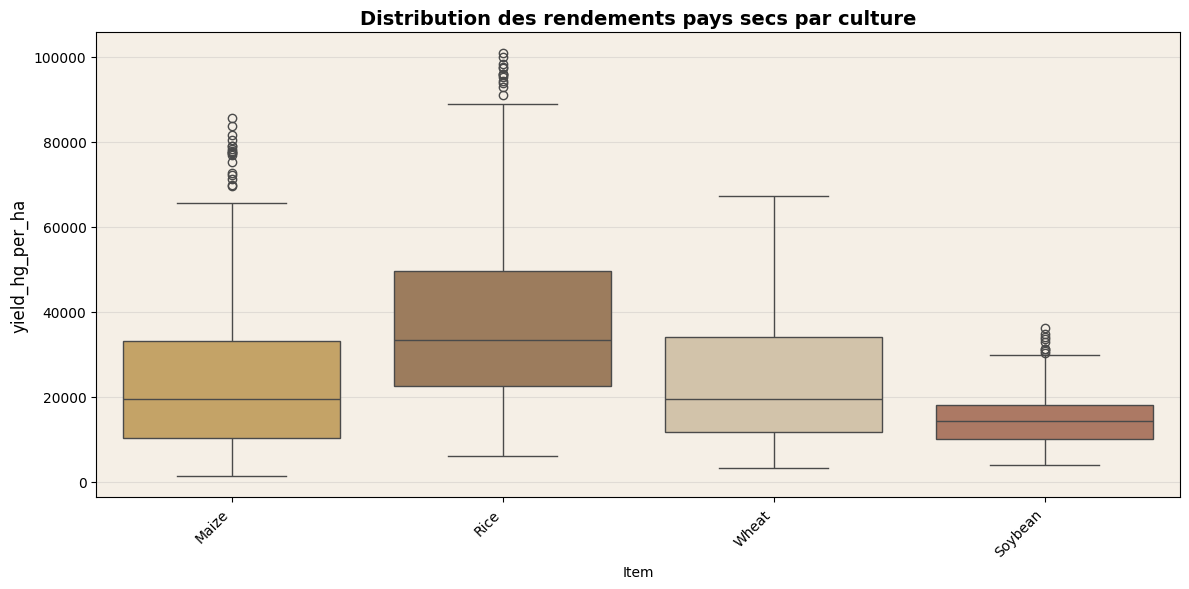

In [18]:
# Boxplot PAR CULTURE - contexte pays secs
couleurs_cultures_seches = [
    '#D4A857',  # Maize - jaune sable désertique
    '#A67C52',  # Potatoes - brun terre argileuse sèche
    '#D9C4A3',  # Rice, paddy - beige terre craquelée (ironie du riz sans eau)
    '#B87458',  # Sorghum - rouge-brun latérite (roi de la sécheresse)
    '#E6C896',  # Wheat - doré paille brûlée
    '#C9824A',  # Sweet potatoes - orange patate douce terreuse
    '#9C9A6E',  # Soybeans - vert olive poussiéreux
    '#D4C09A',  # Cassava - beige racine déshydratée
    '#A88967'   # Yams - brun-ocre tubercule sec
]

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_facecolor('#F5EFE6')  # Fond beige sable clair
sns.boxplot(data=df_pluies_basses, palette=couleurs_cultures_seches, hue="Item", x='Item', y='yield_hg_per_ha', ax=ax)
plt.xticks(rotation=45, ha='right')
plt.ylabel('yield_hg_per_ha', fontsize=12)
plt.title('Distribution des rendements pays secs par culture', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
df_pluies_basses['Area'].unique()

array(['Algeria', 'Egypt', 'Iraq', 'Kazakhstan', 'Libya', 'Mali',
       'Mauritania', 'Montenegro', 'Morocco', 'Namibia', 'Niger', 'Qatar',
       'Saudi Arabia', 'Tunisia'], dtype=object)

C:\Users\Fab\AppData\Local\Temp\ipykernel_16612\1156483336.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


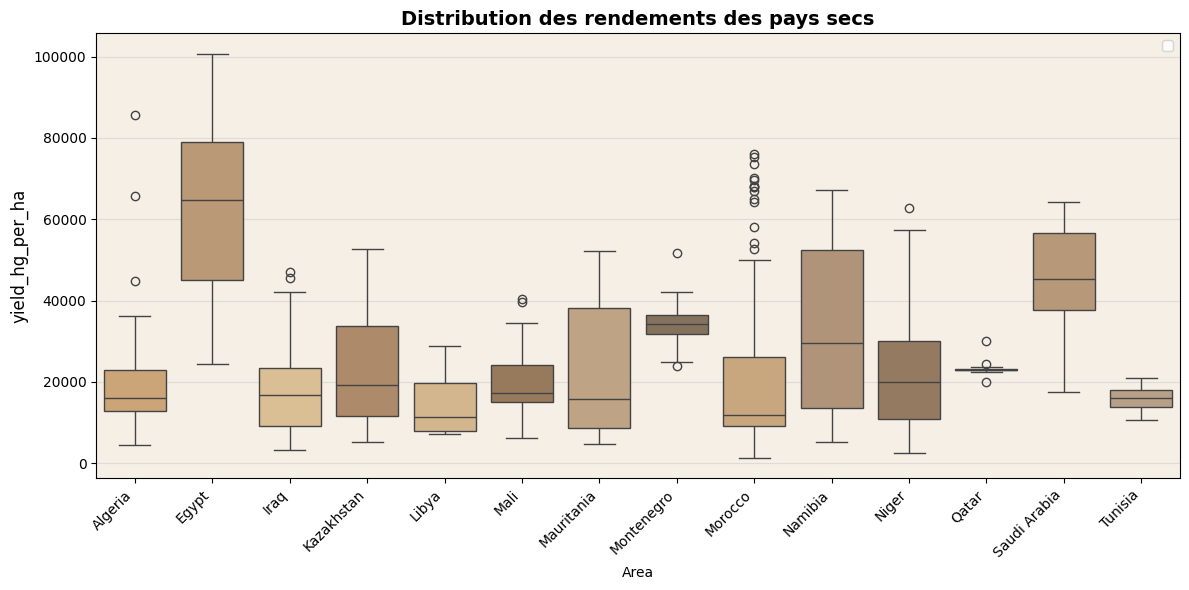

In [20]:
# Boxplot rendements par pays secs
couleurs_pays_desertiques = [
    '#D9A66A',  # Algeria - ocre sahara
    '#C49A6B',  # Bahrain - beige sable du golfe
    '#E6C088',  # Egypt - doré sable du désert
    '#B88A5E',  # Iraq - brun terre mésopotamienne
    '#E0B882',  # Libya - beige dunes claires
    '#A17A52',  # Mali - brun sahel profond
    '#C8A47A',  # Mauritania - ocre moyen
    '#8B7355',  # Montenegro - brun terre aride (+ montagneux)
    '#D4A873',  # Morocco - ocre atlas
    '#B89470',  # Namibia - beige désert de Namibie
    '#9C7A58',  # Niger - brun sahel intense
    '#DCBC92',  # Qatar - beige sable pâle
    '#C2986D',  # Saudi Arabia - ocre arabique
    '#BFA080'   # Tunisia - beige terre méditerranéenne sèche
]

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_facecolor('#F5EFE6')  # Fond beige sable clair (même que les cultures)
sns.boxplot(data=df_pluies_basses, palette=couleurs_pays_desertiques, hue='Area', x='Area', y='yield_hg_per_ha', ax=ax)
plt.legend()
plt.xticks(rotation=45, ha='right')
plt.ylabel('yield_hg_per_ha', fontsize=12)
plt.title('Distribution des rendements des pays secs', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Conclusion :** L'analyse graphique met en évidence une incompatibilité majeure : les zones arides (< 100mm, ex: Égypte) affichent des performances décorrélées de la pluie (irrigation totale)

### Définition du Domaine de Validité
Suite à l'analyse précédente, nous constatons que les climats extrêmes (Temp < 15°C ou Pluie < 100mm) correspondent à des agricultures hors-sol ou hyper-irriguées que le simulateur ne peut pas modéliser. Pour garantir la fiabilité des prédictions, nous restreignons le dataset FAO au domaine de validité du simulateur.

In [21]:
# --- DÉFINITION DU DOMAINE DE VALIDITÉ (SCOPE) ---

# Bornes strictes du simulateur
MIN_TEMP_SIMULATOR = 15.0   # °C
MIN_RAIN_SIMULATOR = 100.0  # mm

# 1. Identification des données Hors Scope
# Pays Froids (Temp < 15°C)
mask_cold = df_fao_consolidated['Temp_Cycle'] < MIN_TEMP_SIMULATOR
df_rejected_cold = df_fao_consolidated[mask_cold]

# Pays Secs / Hyper-Irrigués (Pluie CYCLE < 100mm)
# CORRECTION : On utilise bien Rain_Cycle pour être cohérent avec le simulateur
mask_dry = df_fao_consolidated['Rain_Cycle'] < MIN_RAIN_SIMULATOR
df_rejected_dry = df_fao_consolidated[mask_dry]

# 2. Création du Dataset Valide (Intersection des conditions)
# On garde uniquement si : (Temp >= 15) ET (Pluie_Cycle >= 100)
df_fao_valid = df_fao_consolidated[
    (df_fao_consolidated['Temp_Cycle'] >= MIN_TEMP_SIMULATOR) & 
    (df_fao_consolidated['Rain_Cycle'] >= MIN_RAIN_SIMULATOR)
].copy()

# 3. Calcul des statistiques de rejet
total_before = len(df_fao_consolidated)
total_after = len(df_fao_valid)
total_rejected = total_before - total_after
percent_rejected = (total_rejected / total_before) * 100

# 4. Rapport d'Audit de Nettoyage
print(f"🛡️ APPLICATION DU FILTRE DE VALIDITÉ (Scope Simulateur)")
print(f"-------------------------------------------------------")
print(f"📉 Total lignes FAO avant filtrage : {total_before}")
print(f"🚫 Rejets pour Température (< {MIN_TEMP_SIMULATOR}°C) : {len(df_rejected_cold)} lignes")
print(f"   -> Ex: {list(df_rejected_cold['Area'].unique()[:5])}")
print(f"🚫 Rejets pour Pluie Aride  (< {MIN_RAIN_SIMULATOR}mm/cycle) : {len(df_rejected_dry)} lignes")
print(f"   -> Ex: {list(df_rejected_dry['Area'].unique()[:5])}")
print(f"-------------------------------------------------------")
print(f"✅ Données FAO conservées : {total_after}")
print(f"🗑️ Total rejeté : {total_rejected} lignes ({percent_rejected:.1f}%)")

# 5. Mise à jour officielle
df_fao_consolidated = df_fao_valid.copy()

🛡️ APPLICATION DU FILTRE DE VALIDITÉ (Scope Simulateur)
-------------------------------------------------------
📉 Total lignes FAO avant filtrage : 6532
🚫 Rejets pour Température (< 15.0°C) : 308 lignes
   -> Ex: ['Belarus', 'Canada', 'Denmark', 'Estonia', 'Finland']
🚫 Rejets pour Pluie Aride  (< 100.0mm/cycle) : 859 lignes
   -> Ex: ['Algeria', 'Egypt', 'Iraq', 'Kazakhstan', 'Libya']
-------------------------------------------------------
✅ Données FAO conservées : 5449
🗑️ Total rejeté : 1083 lignes (16.6%)


In [22]:
df_fao_consolidated.head()

,Area,Item,Year,yield_hg_per_ha,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,Temp_Cycle,Rain_Cycle
0,Albania,Maize,1990,36613.0,1485.0,121.0,16.37,24.03873,425.137767
1,Albania,Maize,1991,29068.0,1485.0,121.0,15.36,23.02873,425.137767
2,Albania,Maize,1992,24876.0,1485.0,121.0,16.06,23.72873,425.137767
3,Albania,Maize,1993,24185.0,1485.0,121.0,16.05,23.71873,425.137767
4,Albania,Maize,1994,25848.0,1485.0,201.0,16.96,24.62873,425.137767


## Audit de Robustesse & Préparation "Hybrid Coupling" (Méthode Shahhosseini)

**Contexte :** Maintenant que nous avons garanti la cohérence biophysique entre nos datasets (Scope Climatique), nous devons préparer les données pour l'architecture hybride inspirée de Shahhosseini et al. (2021). Cette méthode repose sur l'apprentissage d'une tendance technologique (yield_trend) et nécessite des séries temporelles robustes.

**Objectifs de cette section :**

1. Audit Temporel : Vérifier la continuité des données (Matrice de disponibilité) et la profondeur historique (Span).
2. Gap Filling : Combler les petits trous (1-2 ans) par interpolation linéaire pour ne pas perdre d'information précieuse.
3. Définition du "Golden Dataset" : Exclure les pays ayant trop peu d'historique pour garantir un apprentissage fiable du Teacher vers le Student.

### Suppression des colonnes inutiles
On supprime les moyennes annuelles globales car elles sont remplacées par les variables 'Smart' calées sur le cycle végétatif (Temp_Cycle, Rain_Cycle).

In [23]:
# Colonnes à supprimer
cols_to_drop = ['average_rain_fall_mm_per_year', 'avg_temp']

# Suppression
df_fao_consolidated.drop(columns=cols_to_drop, inplace=True, errors='ignore')

### Vérification des Unités
**Sanity Check : Unités de Rendement**

On compare les rendements moyens du dataset FAO (Student) et de l'Historique (Teacher) sur les 4 cultures cibles. Si le ratio est proche de 10 000, cela confirme que la FAO est en hg/ha et l'historique en tonnes/ha. Nous convertirons alors la FAO en tonnes pour aligner tout le monde sur le standard métier.

In [24]:
df_historiques.columns

Index(['Region', 'Soil_Type', 'Crop', 'Rainfall_mm', 'Temperature_Celsius',
       'Fertilizer_Used', 'Irrigation_Used', 'Weather_Condition',
       'Days_to_Harvest', 'Yield_tons_per_hectare'],
      dtype='object')

In [25]:
df_historiques['Crop'].unique()

array(['Cotton', 'Rice', 'Barley', 'Soybean', 'Wheat', 'Maize'],
      dtype=object)

In [26]:
target_crops = ['Wheat', 'Maize', 'Rice', 'Soybean']

# 1. Filtrage Historique (Teacher)
df_historiques = df_historiques[df_historiques['Crop'].isin(target_crops)].copy()

# 2. Conversion Unités FAO (Student) : hg -> tonnes
df_fao_consolidated['yield_tonnes_ha'] = df_fao_consolidated['yield_hg_per_ha'] / 10000
df_fao_consolidated.drop(columns=['yield_hg_per_ha'], inplace=True)

# Vérification rapide
print(f"✅ Historique filtré : {df_historiques['Crop'].unique()}")
print(f"✅ FAO convertie (moyenne) : {df_fao_consolidated['yield_tonnes_ha'].mean():.2f} t/ha")

✅ Historique filtré : ['Rice' 'Soybean' 'Wheat' 'Maize']
✅ FAO convertie (moyenne) : 3.12 t/ha


### Audit temporel

#### Matrice de disponibilité

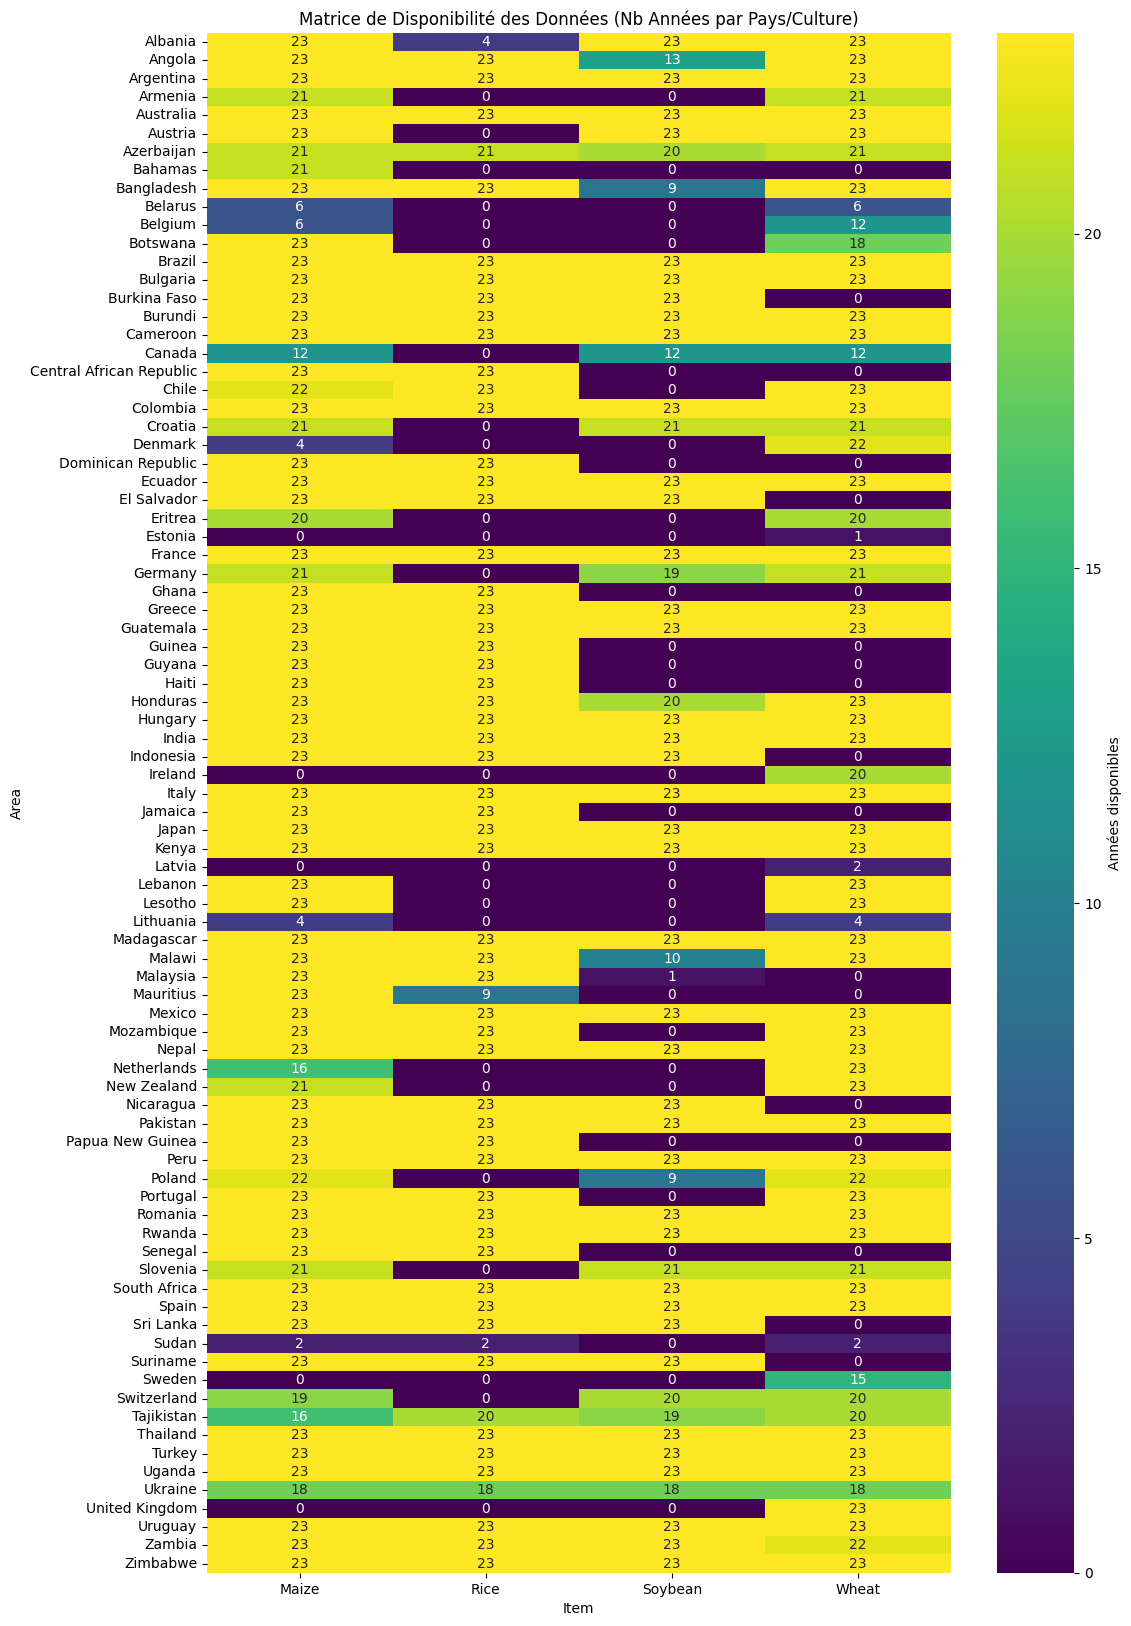

In [27]:
# Création pivot table
df_pivot_fao = pd.pivot_table(df_fao_consolidated, values='Year', index='Area', columns=['Item'], aggfunc='count').fillna(0)

# Visualisation (Heatmap)
plt.figure(figsize=(12, 20)) # Grande hauteur car beaucoup de pays
sns.heatmap(df_pivot_fao, annot=True, fmt='g', cmap='viridis', cbar_kws={'label': 'Années disponibles'})
plt.title('Matrice de Disponibilité des Données (Nb Années par Pays/Culture)')
plt.show()

#### Analyse de la Matrice de disponibilité

**Diagnostic Visuel :**
Cette heatmap révèle la structure "trouée" (Sparse Data) de notre jeu de données.

1.  **Spécialisation Agronomique :**
    * Les "trous" ne sont pas forcément des données manquantes, mais souvent une **réalité agronomique** (ex: La Suède ne cultive pas de Riz, l'Égypte ne cultive pas de Soja sans irrigation intensive).
    * Il est inutile de vouloir forcer le modèle à prédire ces cases vides.

2.  **Disparité de Profondeur :**
    * Certains pays (ex: USA, France, Brésil) sont des "bons élèves" avec des séries complètes (~25-30 ans).
    * D'autres (ex: Albanie, petits pays) n'ont que des fragments d'historique (< 10 ans).

**Décision Stratégique (Golden Dataset) :**
Pour l'architecture Shahhosseini (qui nécessite d'apprendre une tendance `Yield_Trend`), nous ne pouvons pas conserver les séries trop courtes.
> **Action à suivre :** Nous allons calculer le "Span" (Durée de vie) de chaque série et appliquer un seuil de coupure (Thresholding) pour ne garder que les couples Pays/Culture robustes.

#### Analyse du span (durée de vie)

Aperçu des séries courtes (Span < 10 ans) :
                     min   max  span_years
Area       Item                           
Albania    Rice     1990  1993           3
Bangladesh Soybean  2005  2013           8
Denmark    Maize    2010  2013           3
Estonia    Wheat    2008  2008           0
Latvia     Wheat    2000  2008           8


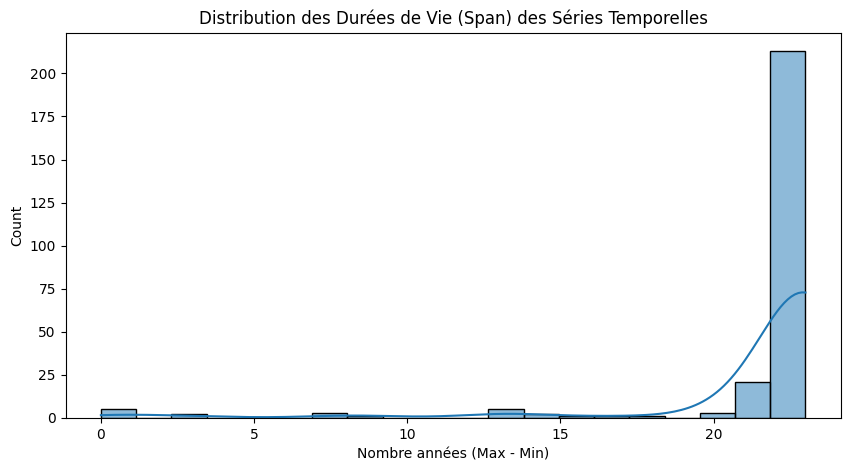

In [28]:
# 1. On groupe et on récupère Min/Max
# Correction : crochets simples pour la liste des colonnes
df_span = df_fao_consolidated.groupby(['Area', 'Item'])['Year'].agg(['min', 'max'])

# 2. On calcule la soustraction (La durée de vie)
# On ajoute une nouvelle colonne 'span_years'
df_span['span_years'] = df_span['max'] - df_span['min']

# 3. Visualisation des "mauvais élèves" (ceux qui ont moins de 10 ans de span)
print("Aperçu des séries courtes (Span < 10 ans) :")
print(df_span[df_span['span_years'] < 10].head())

# 4. Visualisation de la distribution (Exercice demandé)
plt.figure(figsize=(10, 5))
sns.histplot(df_span['span_years'], bins=20, kde=True)
plt.title('Distribution des Durées de Vie (Span) des Séries Temporelles')
plt.xlabel('Nombre années (Max - Min)')
plt.show()

La grande majorité des couples (Pays + Culture) ont des données qui couvrent toute la période (1990-2013).

Conséquence technique : Cela signifie qu'on pourra calculer un yield_trend (la pente du progrès technologique) fiable.

### Gap filling (Interpolation linéaire)

In [29]:
df_fao_consolidated.columns

Index(['Area', 'Item', 'Year', 'pesticides_tonnes', 'Temp_Cycle', 'Rain_Cycle',
       'yield_tonnes_ha'],
      dtype='object')

In [30]:
# 1. Pivot : On met les années en colonnes pour aligner le temps
# Cela crée une grille où les trous apparaissent comme NaN
df_pivot_col_annee = df_fao_consolidated.pivot_table(
    index=['Area', 'Item'],
    columns='Year',
    values='yield_tonnes_ha'
)

In [31]:
df_pivot_col_annee.head()

Year               1990    1991    1992    1993    1994    1995    1996  \
Area    Item                                                              
Albania Maize    3.6613  2.9068  2.4876  2.4185  2.5848  3.1300  3.2604   
        Rice     2.3333  2.8538  4.0000  4.1786     NaN     NaN     NaN   
        Soybean  0.7000  0.6066  0.4507  0.7998  0.7927  1.1791  1.5480   
        Wheat    3.0197  2.0698  2.4388  2.9976  2.4745  2.8703  2.1741   
Angola  Maize    0.2736  0.4013  0.3778  0.2627  0.2463  0.3517  0.6993   

Year               1997    1998    1999  ...    2004    2005    2006    2007  \
Area    Item                             ...                                   
Albania Maize    3.1862  3.3416  3.7455  ...  4.6197  4.5442  5.0111  4.6732   
        Rice        NaN     NaN     NaN  ...     NaN     NaN     NaN     NaN   
        Soybean  1.2768  1.4327  1.7143  ...  1.3333  1.7500  2.0000  2.0000   
        Wheat    2.8516  2.8037  2.4954  ...  3.1130  3.1582  3.0787  3.5496   
Angola  Maize    0.5959  0.7396  0.6361  ...  0.5404  0.6736  0.4687  0.5091   

Year               2008    2009    2010    2011    2012    2013  
Area    Item                                                     
Albania Maize    5.0000  5.5693  6.6790  5.9869  6.7290  6.9533  
        Rice        NaN     NaN     NaN     NaN     NaN     NaN  
        Soybean  2.0000  1.6667  1.6667  1.8519  1.3333  1.0000  
        Wheat    4.0168  4.0229  3.9905  4.2301  4.1096  4.1292  
Angola  Maize    0.7946  0.6614  0.7200  0.7376  0.7770  0.9467  

[5 rows x 23 columns]

In [32]:
# 2. Interpolation
# limit=2 : On ne comble pas si le trou fait plus de 2 ans
# limit_area='inside' : CRITIQUE. On ne comble que les trous AU MILIEU.
# On n'invente pas de données avant la première année ni après la dernière.
df_interpolated = df_pivot_col_annee.interpolate(method='linear', axis=1, limit=2, limit_area='inside')

# 3. Retour au format Long (Melt)
df_filled = df_interpolated.reset_index().melt(
    id_vars=['Area', 'Item'],
    var_name='Year',
    value_name='yield_tonnes_ha'
)

In [33]:
df_filled.head()

,Area,Item,Year,yield_tonnes_ha
0,Albania,Maize,1990,3.6613
1,Albania,Rice,1990,2.3333
2,Albania,Soybean,1990,0.7000
3,Albania,Wheat,1990,3.0197
4,Angola,Maize,1990,0.2736


In [34]:
df_filled.isna().sum()

Area                 0
Item                 0
Year                 0
yield_tonnes_ha    390
dtype: int64

In [35]:
print(f"Taille avant suppression des rendements vides {df_filled.shape}")

# 4. Nettoyage : On retire les lignes qui sont restées vides (les bouts non interpolés)
df_filled = df_filled.dropna(subset=['yield_tonnes_ha'])

print(f"Taille après suppression des rendements vides {df_filled.shape}")

Taille avant suppression des rendements vides (5934, 4)
Taille après suppression des rendements vides (5544, 4)


In [36]:
# 5. Réintégration des colonnes climatiques (Rain_Cycle, Temp_Cycle)
# Comme on a touché aux lignes, il faut remettre la météo en face des années.
# On fait une fusion gauche pour récupérer la météo du dataset original
cols_meteo = ['Area', 'Item', 'Year', 'Rain_Cycle', 'Temp_Cycle', 'pesticides_tonnes']
df_final_prepared = pd.merge(
    df_filled,
    df_fao_consolidated[cols_meteo],
    on=['Area', 'Item', 'Year'],
    how='left'
)

# Comparaison Avant / Après
print(f"Lignes avant interpolation : {len(df_fao_consolidated)}")
print(f"Lignes après interpolation : {len(df_final_prepared)}")
print(f"Gain (Trous comblés) : {len(df_final_prepared) - len(df_fao_consolidated)}")

# Sauvegarde dans la variable principale
df_fao_consolidated = df_final_prepared.copy()

# Aperçu
df_fao_consolidated.sort_values(by=['Area', 'Item', 'Year']).head()

Lignes avant interpolation : 5449
Lignes après interpolation : 5544
Gain (Trous comblés) : 95


,Area,Item,Year,yield_tonnes_ha,Rain_Cycle,Temp_Cycle,pesticides_tonnes
0,Albania,Maize,1990,3.6613,425.137767,24.03873,121.0
218,Albania,Maize,1991,2.9068,425.137767,23.02873,121.0
435,Albania,Maize,1992,2.4876,425.137767,23.72873,121.0
673,Albania,Maize,1993,2.4185,425.137767,23.71873,121.0
914,Albania,Maize,1994,2.5848,425.137767,24.62873,201.0


### Sélection et visualisation

In [37]:
df_span.head()

min   max  span_years
Area    Item                           
Albania Maize    1990  2013          23
        Rice     1990  1993           3
        Soybean  1990  2013          23
        Wheat    1990  2013          23
Angola  Maize    1990  2013          23

In [38]:
MIN_YEARS_THRESHOLD = 12  # Seuil de robustesse (phénomène sur au moins une décennie.)

# 1. On récupère l'info 'span_years' dans le dataset principal
# On utilise map pour coller la valeur correspondante à chaque ligne Area/Item
df_fao_consolidated['span_years'] = df_fao_consolidated.set_index(['Area', 'Item']).index.map(df_span['span_years'])

# 2. Filtrage : On ne garde que les "Bons Élèves"
df_golden = df_fao_consolidated[df_fao_consolidated['span_years'] >= MIN_YEARS_THRESHOLD].copy()

# 3. Statistiques de nettoyage
n_removed = len(df_fao_consolidated) - len(df_golden)
percent_removed = (n_removed / len(df_fao_consolidated)) * 100

print(f"📉 Seuil de coupure : {MIN_YEARS_THRESHOLD} ans minimum")
print(f"🗑️ Lignes supprimées (Séries trop courtes) : {n_removed} ({percent_removed:.1f}%)")
print(f"✅ TAILLE DU GOLDEN DATASET : {len(df_golden)} lignes")

# Mise à jour du dataset principal
df_fao_consolidated = df_golden.copy()

# Aperçu des survivants
print(f"\nNombre de pays restants : {df_fao_consolidated['Area'].nunique()}")
print("Répartition par culture :")
print(df_fao_consolidated['Item'].value_counts())

📉 Seuil de coupure : 12 ans minimum
🗑️ Lignes supprimées (Séries trop courtes) : 48 (0.9%)
✅ TAILLE DU GOLDEN DATASET : 5496 lignes

Nombre de pays restants : 81
Répartition par culture :
Item
Maize      1698
Wheat      1383
Rice       1316
Soybean    1099
Name: count, dtype: int64


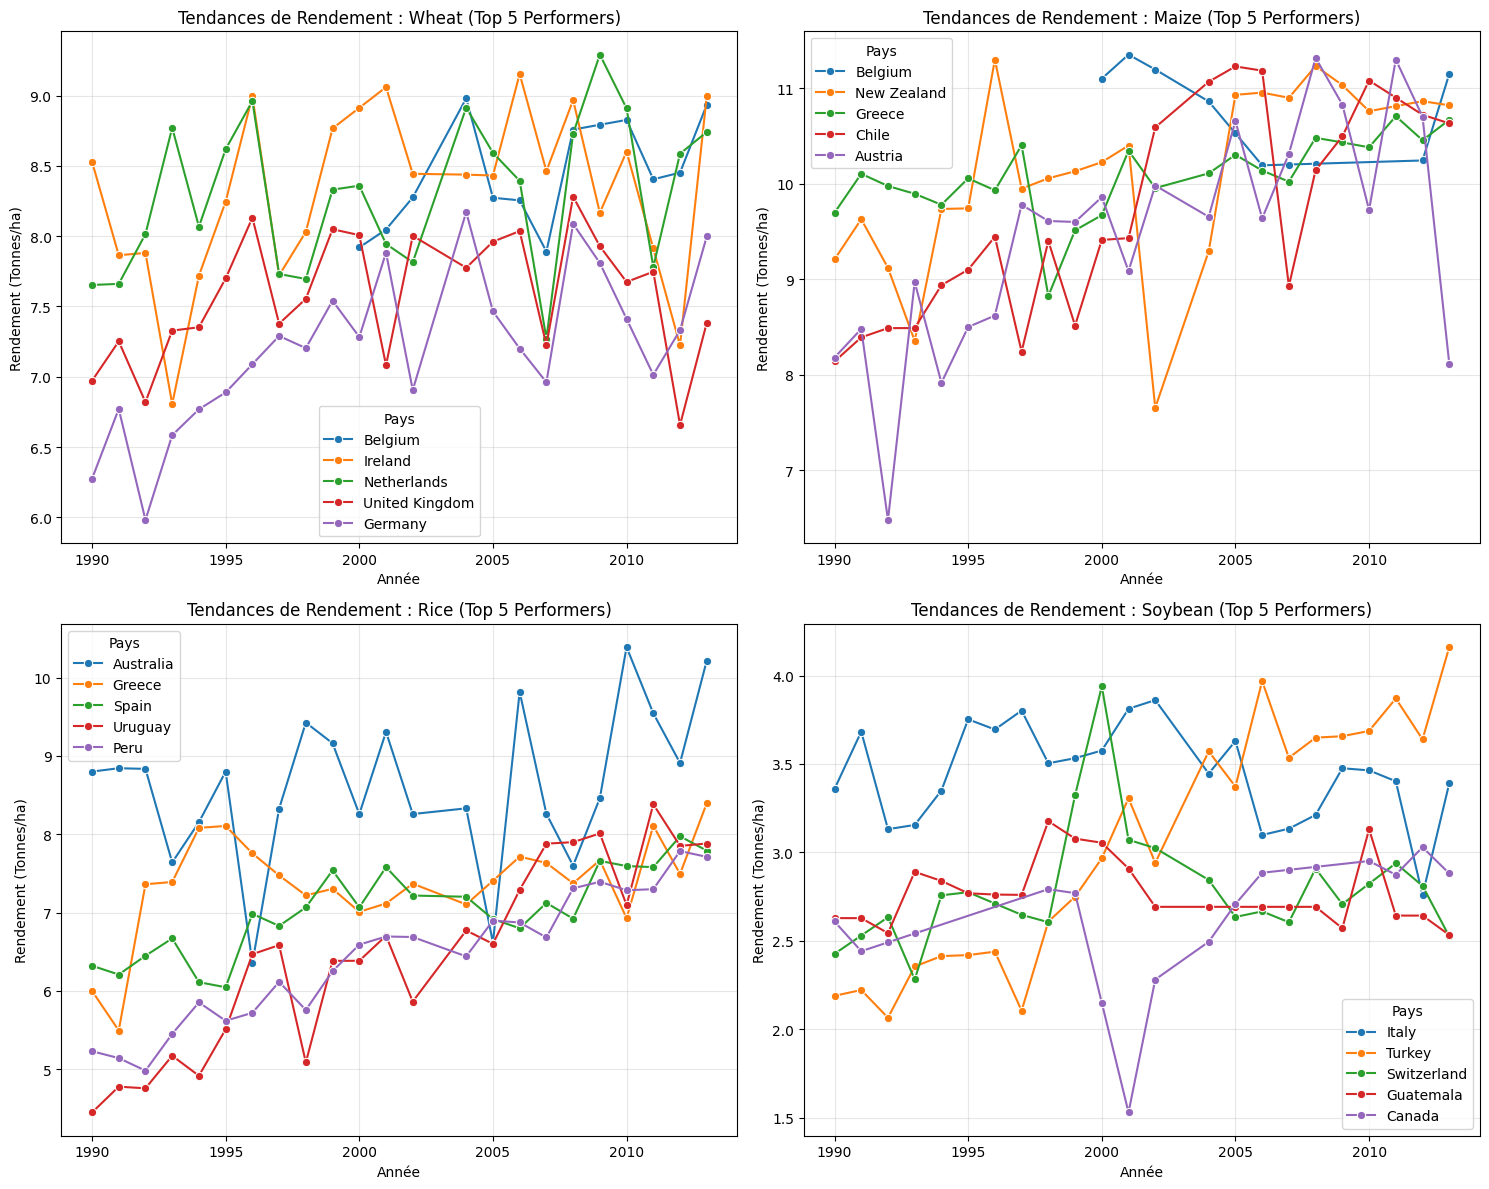

In [39]:
# Liste des cultures
crops = ['Wheat', 'Maize', 'Rice', 'Soybean']
colors = {'Wheat': 'gold', 'Maize': 'orange', 'Rice': 'brown', 'Soybean': 'green'}

# Création d'une grille de graphiques (2x2)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, crop in enumerate(crops):
    ax = axes[i]
    
    # 1. Filtrer pour la culture en cours
    df_crop = df_fao_consolidated[df_fao_consolidated['Item'] == crop]
    
    # 2. Identifier les 5 plus gros producteurs 
    top_countries = df_crop.groupby('Area')['yield_tonnes_ha'].mean().nlargest(5).index.tolist()
    
    # 3. Tracer les courbes
    for country in top_countries:
        data = df_crop[df_crop['Area'] == country]
        sns.lineplot(data=data, x='Year', y='yield_tonnes_ha', ax=ax, label=country, marker='o')
    
    # Cosmétique
    ax.set_title(f'Tendances de Rendement : {crop} (Top 5 Performers)')
    ax.set_ylabel('Rendement (Tonnes/ha)')
    ax.set_xlabel('Année')
    ax.grid(True, alpha=0.3)
    ax.legend(title='Pays')

plt.tight_layout()
plt.show()

**Observations Visuelles :**
L'examen des séries temporelles sur les principaux producteurs révèle une structure composite du rendement agricole :

1.  **La Tendance de Fond (Signal Technologique) :** Sur la période observée (1990-2013), on note une tendance haussière globale, particulièrement marquée pour le Maïs. Cette composante reflète l'amélioration continue des pratiques agricoles (génétique, intrants, mécanisation).
2.  **La Volatilité Inter-annuelle (Signal Climatique) :** Les courbes ne sont pas lisses mais présentent une forte irrégularité en "dents de scie". Ces décrochages brutaux (ex: 2007 pour le blé) sont synchrones entre plusieurs pays, trahissant l'impact d'événements climatiques majeurs (sécheresse, canicule).

**Justification de l'Architecture "Coupling" :**
Cette observation visuelle valide l'approche de *Shahhosseini et al.* :
* Le modèle ne peut pas apprendre la **Météo** s'il est brouillé par la **Technologie**.
* **Stratégie :** Nous allons isoler la tendance technologique par régression linéaire (`Yield_Trend`) pour permettre au modèle de Machine Learning de se concentrer uniquement sur l'explication des résidus (les écarts dus au climat).

### Corrélation pluie-rendement
Objectif : Vérifier si le lien Météo -> Rendement est visible à l'oeil nu.

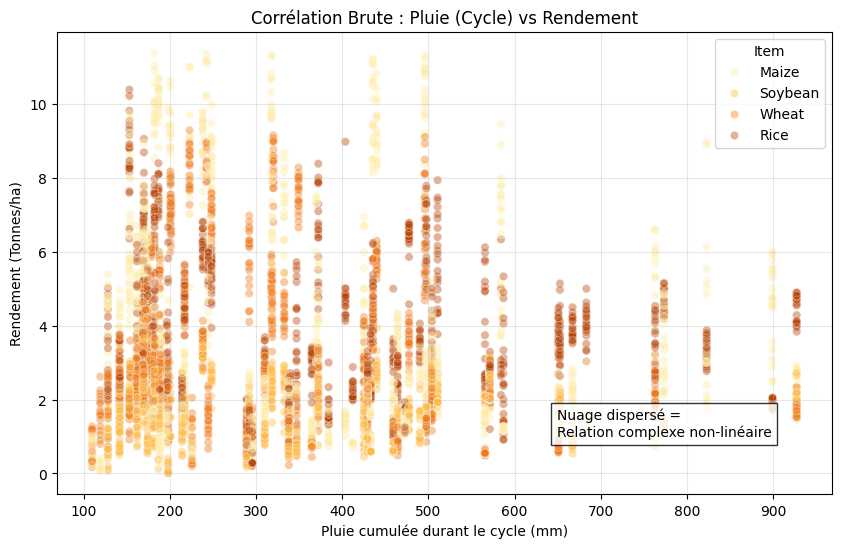

In [40]:
plt.figure(figsize=(10, 6))

# On utilise un scatter plot avec transparence (alpha) pour voir la densité
sns.scatterplot(
    data=df_fao_consolidated, 
    x='Rain_Cycle', 
    y='yield_tonnes_ha', 
    hue='Item', 
    alpha=0.4, 
    palette='YlOrBr'
)

plt.title('Corrélation Brute : Pluie (Cycle) vs Rendement')
plt.xlabel('Pluie cumulée durant le cycle (mm)')
plt.ylabel('Rendement (Tonnes/ha)')
plt.grid(True, alpha=0.3)

# Ajout d'une note pédagogique dans le graphe
plt.text(x=df_fao_consolidated['Rain_Cycle'].max()*0.7, y=1, 
         s="Nuage dispersé =\nRelation complexe non-linéaire", 
         bbox=dict(facecolor='white', alpha=0.8))

plt.show()

Ce graphe met en évidence qu'il n'y a pas de "chiffre magique" de pluie (ex: "plus il pleut, mieux c'est"). Il y a un optimum, et cela dépend de la plante. C'est la preuve qu'il faut un Random Forest ou un XGBoost pour décrypter ce nuage.

### Feature Engineering Yield-Trend
**Problématique :**
Comme observé sur les graphiques précédents, le rendement agricole (`Yield`) est le résultat de deux forces opposées :
1.  **Le Progrès Technologique (Low Frequency) :** Une augmentation structurelle et lente due à l'amélioration des semences, des engrais et de la mécanisation.
2.  **L'Aléa Climatique (High Frequency) :** Des fluctuations annuelles brutales dues à la météo (pluie, température).

**Stratégie Shahhosseini :**
Pour maximiser la performance du modèle "Student", nous ne devons pas lui demander d'apprendre ces deux signaux en même temps. Nous allons appliquer une stratégie de **"Detrending"** (suppression de tendance) :
* Nous calculons une régression linéaire simple pour chaque couple (Pays/Culture) : c'est le **`Yield_Trend`**.
* Ce feature sera fourni au modèle. Ainsi, le modèle de Machine Learning (XGBoost/Random Forest) pourra se concentrer sur sa véritable valeur ajoutée : prédire les **écarts** par rapport à cette tendance (les résidus) en fonction des variables climatiques.

⏳ Calcul des tendances technologiques (Linear Regression) par pays/culture...


C:\Users\Fab\AppData\Local\Temp\ipykernel_16612\1282296426.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_fao_consolidated = df_fao_consolidated.groupby(['Area', 'Item'], group_keys=False).apply(calculate_trend)


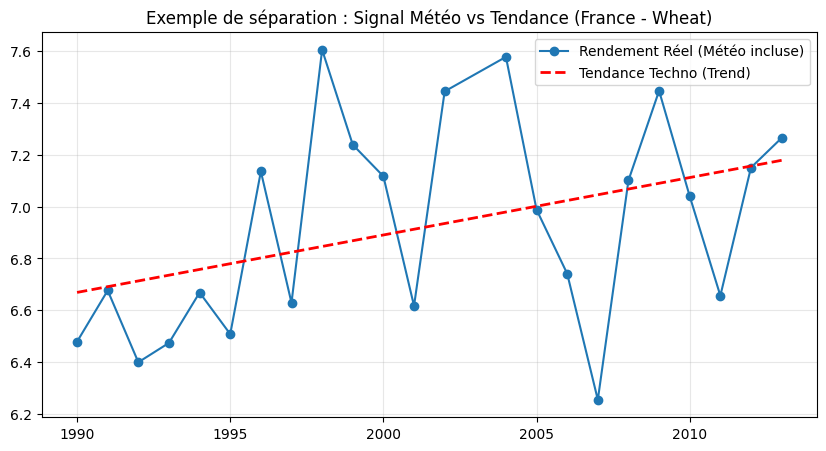

✅ Feature 'yield_trend' calculée et ajoutée.


,Area,Item,Year,yield_tonnes_ha,Rain_Cycle,Temp_Cycle,pesticides_tonnes,span_years,yield_trend
0,Albania,Maize,1990,3.6613,425.137767,24.03873,121.0,23,2.223846
2,Albania,Soybean,1990,0.7000,425.137767,24.03873,121.0,23,0.925042
3,Albania,Wheat,1990,3.0197,425.137767,24.03873,121.0,23,2.256730
4,Angola,Maize,1990,0.2736,289.150939,31.78873,64.0,23,0.346792
5,Angola,Rice,1990,0.9512,289.150939,31.78873,64.0,23,1.348230


In [41]:
# 1. Préparation de la structure pour stocker les résultats
# On va créer un dictionnaire pour stocker les modèles ou les pentes si besoin,
# mais ici on veut surtout injecter la colonne 'yield_trend' dans le dataframe.

def calculate_trend(group):
    # On prépare X (Année) et y (Rendement)
    X = group[['Year']].values
    y = group['yield_tonnes_ha'].values
    
    # On fit la régression linéaire sur ce groupe spécifique (Pays/Culture)
    model = LinearRegression()
    model.fit(X, y)
    
    # On prédit la tendance sur les années existantes
    # Ce sont les points alignés sur la droite "théorique"
    group['yield_trend'] = model.predict(X)
    
    return group

# 2. Application de la fonction par groupe (Pays + Culture)
# Cela peut prendre quelques secondes
print("⏳ Calcul des tendances technologiques (Linear Regression) par pays/culture...")
df_fao_consolidated = df_fao_consolidated.groupby(['Area', 'Item'], group_keys=False).apply(calculate_trend)

# 3. Vérification visuelle
# On reprend un pays au hasard (ex: France, Blé) pour voir la différence Réel vs Trend
subset = df_fao_consolidated[(df_fao_consolidated['Area'] == 'France') & 
                             (df_fao_consolidated['Item'] == 'Wheat')]

if not subset.empty:
    plt.figure(figsize=(10, 5))
    plt.plot(subset['Year'], subset['yield_tonnes_ha'], label='Rendement Réel (Météo incluse)', marker='o')
    plt.plot(subset['Year'], subset['yield_trend'], label='Tendance Techno (Trend)', linestyle='--', color='red', linewidth=2)
    plt.title("Exemple de séparation : Signal Météo vs Tendance (France - Wheat)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

print("✅ Feature 'yield_trend' calculée et ajoutée.")
df_fao_consolidated.head()

**Interprétation du visuel (Exemple France/Blé) :**
Ce graphique illustre parfaitement la logique de notre architecture hybride :
* 🔴 **La Ligne Rouge (`yield_trend`) :** Représente le potentiel théorique du pays. Elle capture l'évolution des infrastructures et du savoir-faire agricole. C'est une information que le climat ne peut pas expliquer.
* 🔵 **La Courbe Bleue (`yield_tonnes_ha`) :** C'est la réalité terrain. On voit clairement que certaines années (ex: 2007), la réalité décroche brutalement sous la ligne rouge.

**Conclusion pour la Modélisation :**
La distance verticale entre la ligne rouge et le point bleu est **l'impact net de la météo** (et des nuisibles).
C'est précisément cette "delta" que notre modèle devra apprendre à prédire en utilisant les features `Rain_Cycle` et `Temp_Cycle`. Sans cette feature `yield_trend`, le modèle aurait été aveugle au contexte technologique du pays.

## Sauvegardes 

In [42]:
# ==============================================================================
# SAUVEGARDE FINALE POUR MODÉLISATION (Shahhosseini Ready)
# ==============================================================================

# 1. Définition des noms de fichiers explicites
filename_teacher = "dataset_teacher_historique.csv"
filename_student = "dataset_student_fao.csv"

# 2. Construction des chemins complets (Pathlib)
save_path_teacher = DONNEES_PROCESSED / filename_teacher
save_path_student = DONNEES_PROCESSED / filename_student

# 3. Enregistrement sur le disque
print("💾 Sauvegarde des datasets en cours...")

# On retire l'index pandas (0,1,2...) qui est inutile dans le CSV
df_historiques.to_csv(save_path_teacher, index=False)
df_fao_consolidated.to_csv(save_path_student, index=False)

# 4. Confirmation visuelle
print("-" * 50)
print(f"✅ DATASET TEACHER (Simulateur) : Sauvegardé sous '{filename_teacher}'")
print(f"   -> Volume : {len(df_historiques)} lignes")
print(f"✅ DATASET STUDENT (Golden FAO) : Sauvegardé sous '{filename_student}'")
print(f"   -> Volume : {len(df_fao_consolidated)} lignes")
print("-" * 50)
print("🚀 PRÊT POUR L'ARCHITECTURE HYBRIDE (Notebook Suivant)")

💾 Sauvegarde des datasets en cours...
--------------------------------------------------
✅ DATASET TEACHER (Simulateur) : Sauvegardé sous 'dataset_teacher_historique.csv'
   -> Volume : 666494 lignes
✅ DATASET STUDENT (Golden FAO) : Sauvegardé sous 'dataset_student_fao.csv'
   -> Volume : 5496 lignes
--------------------------------------------------
🚀 PRÊT POUR L'ARCHITECTURE HYBRIDE (Notebook Suivant)
